<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Load the dataset directly from URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_path)

# Display the first few rows of the data to understand its structure
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()


Dataset shape: (65437, 114)

First few rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


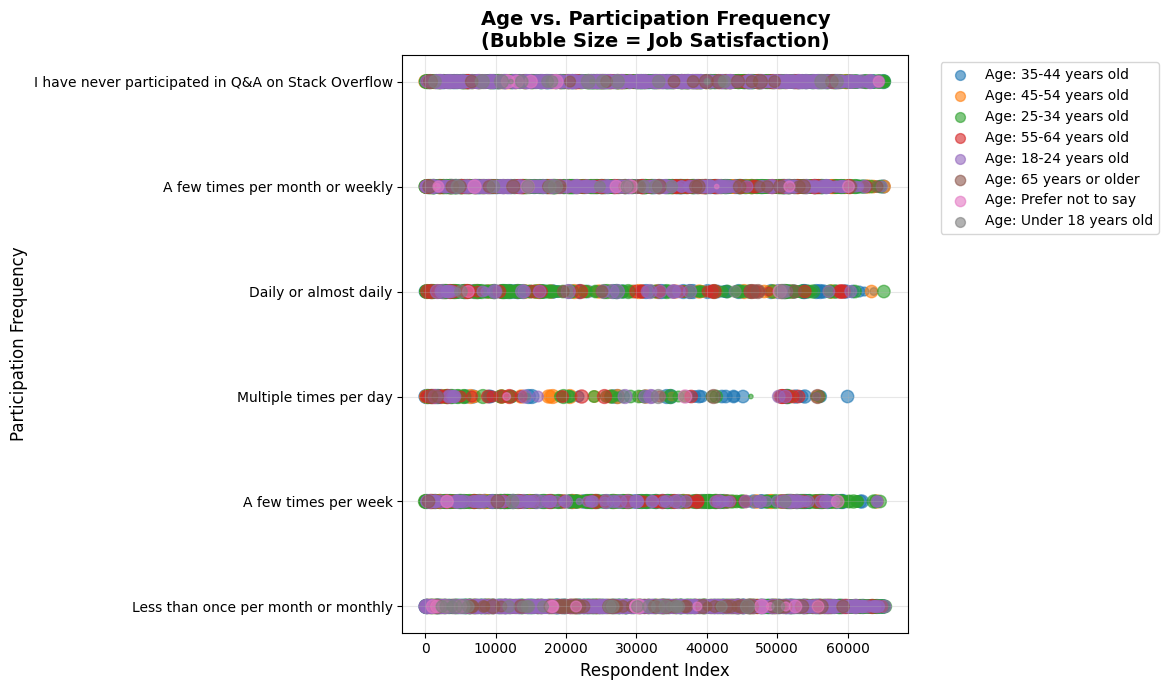

In [4]:
# Task 1.1: Bubble Plot for Age vs. Participation Frequency
# Clean the data and remove missing values
df_clean = df[['Age', 'SOPartFreq', 'JobSat']].dropna()

# Convert to numeric where needed
df_clean['JobSat'] = pd.to_numeric(df_clean['JobSat'], errors='coerce')
df_clean = df_clean.dropna()

# Create age categories for better visualization
df_clean['Age_group'] = df_clean['Age'].astype(str)

# Create bubble plot
plt.figure(figsize=(12, 7))
for age in df_clean['Age_group'].unique():
    df_age = df_clean[df_clean['Age_group'] == age]
    plt.scatter(df_age.index, df_age['SOPartFreq'], 
               s=df_age['JobSat']*10, alpha=0.6, label=f'Age: {age}')

plt.xlabel('Respondent Index', fontsize=12)
plt.ylabel('Participation Frequency', fontsize=12)
plt.title('Age vs. Participation Frequency\n(Bubble Size = Job Satisfaction)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


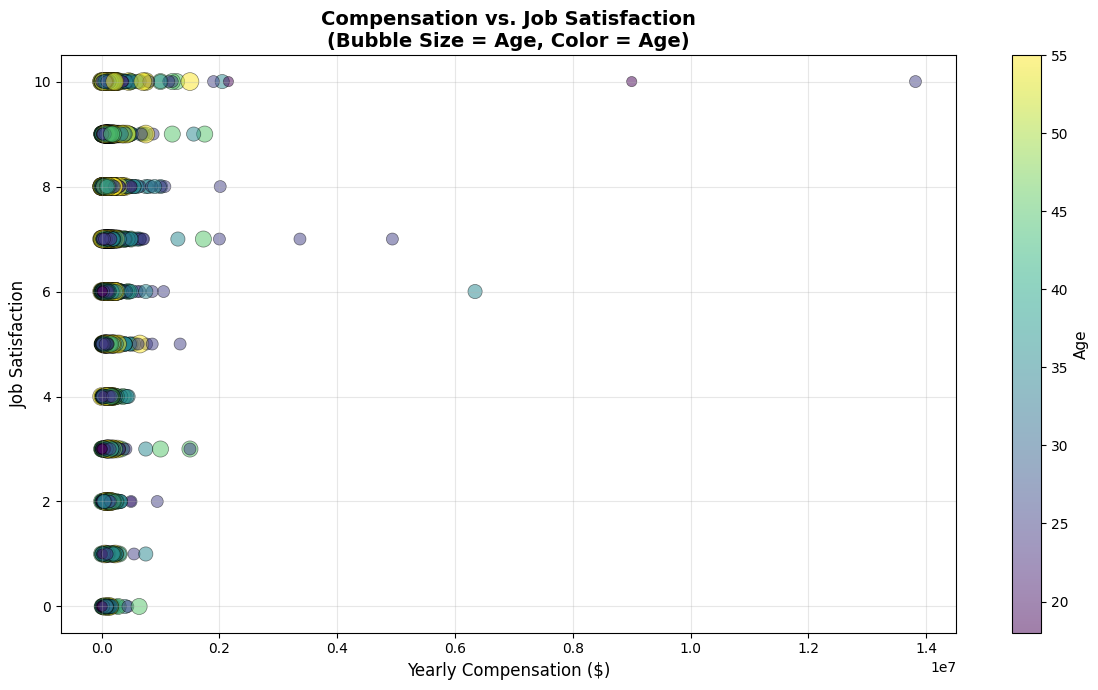

In [12]:
# Task 1.2: Bubble Plot for Compensation vs. Job Satisfaction
# Parse age from various formats (ranges like "25-34", "24 years old", etc.)
def parse_age(age_str):
    import re
    if pd.isna(age_str):
        return None
    age_str = str(age_str).strip()
    if 'years old' in age_str:
        try:
            nums = re.findall(r'\d+', age_str)
            if nums:
                return float(nums[0])
        except:
            return None
    try:
        return float(age_str)
    except:
        return None

# Clean the data
df_clean = df[['ConvertedCompYearly', 'JobSat', 'Age']].dropna()

# Convert to numeric
df_clean['ConvertedCompYearly'] = pd.to_numeric(df_clean['ConvertedCompYearly'], errors='coerce')
df_clean['JobSat'] = pd.to_numeric(df_clean['JobSat'], errors='coerce')
df_clean['Age_numeric'] = df_clean['Age'].apply(parse_age)
df_clean = df_clean[df_clean['Age_numeric'].notna()].dropna()

# Create bubble plot
plt.figure(figsize=(12, 7))
scatter = plt.scatter(df_clean['ConvertedCompYearly'], df_clean['JobSat'],
                     s=df_clean['Age_numeric']*3, alpha=0.5, c=df_clean['Age_numeric'],
                     cmap='viridis', edgecolors='black', linewidth=0.5)

plt.xlabel('Yearly Compensation ($)', fontsize=12)
plt.ylabel('Job Satisfaction', fontsize=12)
plt.title('Compensation vs. Job Satisfaction\n(Bubble Size = Age, Color = Age)', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter)
cbar.set_label('Age', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



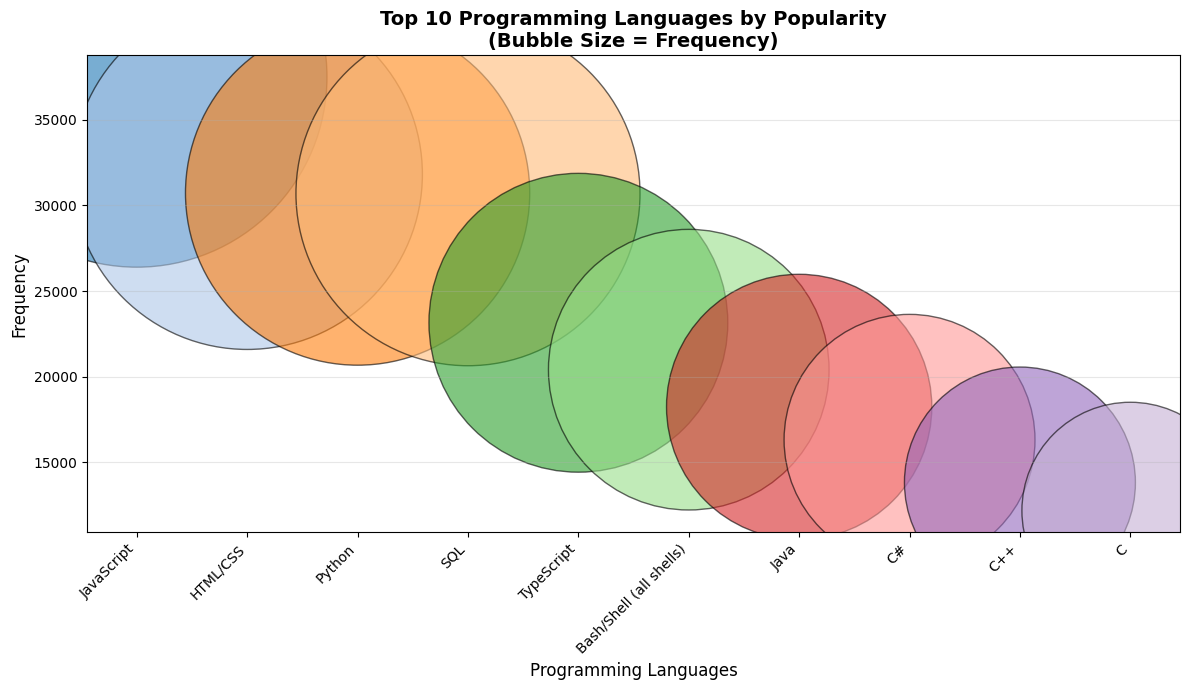

In [6]:
# Task 2.1: Bubble Plot of Technology Preferences by Age
# Extract and count programming languages
df_languages = df[['LanguageHaveWorkedWith', 'Age']].dropna()

# Split languages and count frequencies
language_counts = {}
for langs in df_languages['LanguageHaveWorkedWith']:
    for lang in str(langs).split(';'):
        lang = lang.strip()
        if lang:
            language_counts[lang] = language_counts.get(lang, 0) + 1

# Get top 10 languages
top_langs = sorted(language_counts.items(), key=lambda x: x[1], reverse=True)[:10]
top_lang_names = [x[0] for x in top_langs]
top_lang_counts = [x[1] for x in top_langs]

# Create bubble plot
plt.figure(figsize=(12, 7))
colors = plt.cm.tab20(range(len(top_lang_names)))
plt.scatter(range(len(top_lang_names)), top_lang_counts, 
           s=[count*2 for count in top_lang_counts], 
           alpha=0.6, c=colors, edgecolors='black', linewidth=1)

plt.xlabel('Programming Languages', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 10 Programming Languages by Popularity\n(Bubble Size = Frequency)', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_lang_names)), top_lang_names, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


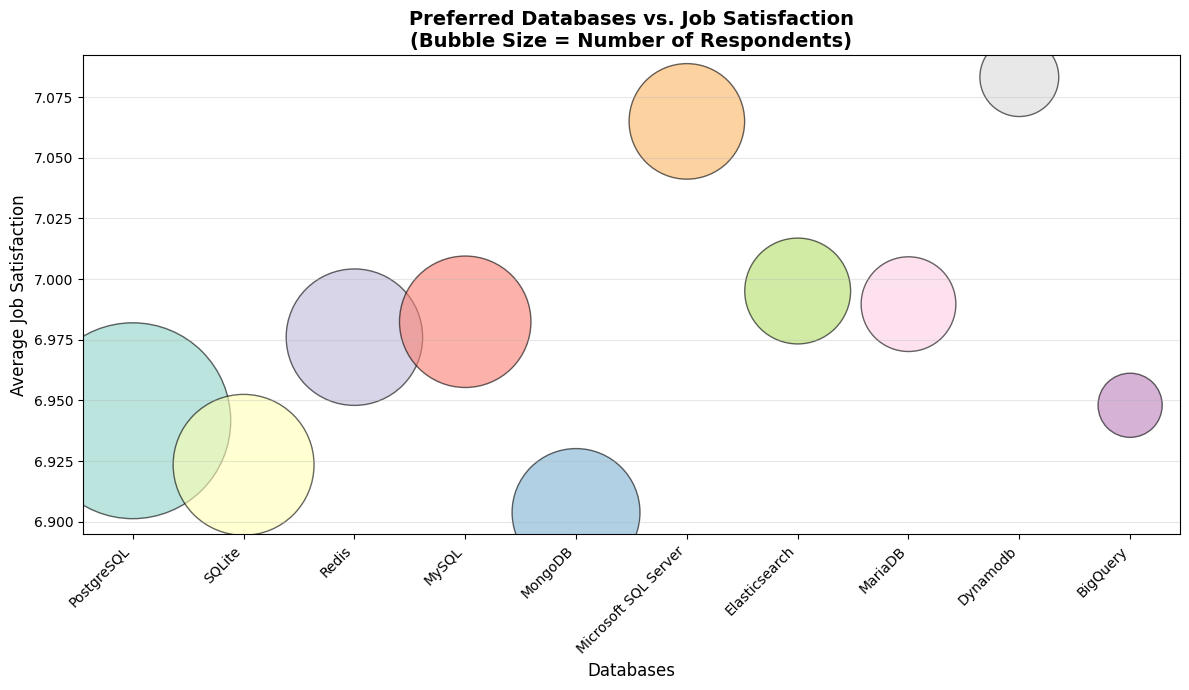

In [7]:
# Task 2.2: Bubble Plot for Preferred Databases vs. Job Satisfaction
# Extract databases and job satisfaction
df_db = df[['DatabaseWantToWorkWith', 'JobSat']].dropna()

# Split databases and count frequencies for each
db_counts = {}
db_satisfaction = {}

for idx, row in df_db.iterrows():
    dbs = str(row['DatabaseWantToWorkWith']).split(';')
    for db in dbs:
        db = db.strip()
        if db:
            if db not in db_counts:
                db_counts[db] = 0
                db_satisfaction[db] = []
            db_counts[db] += 1
            db_satisfaction[db].append(pd.to_numeric(row['JobSat'], errors='coerce'))

# Get top 10 databases and calculate average satisfaction
top_dbs = sorted(db_counts.items(), key=lambda x: x[1], reverse=True)[:10]
db_names = [x[0] for x in top_dbs]
db_freqs = [x[1] for x in top_dbs]
db_avg_sat = [sum([s for s in db_satisfaction[db] if pd.notna(s)])/len([s for s in db_satisfaction[db] if pd.notna(s)]) 
              for db in db_names]

# Create bubble plot
plt.figure(figsize=(12, 7))
colors = plt.cm.Set3(range(len(db_names)))
plt.scatter(range(len(db_names)), db_avg_sat,
           s=[freq*1.5 for freq in db_freqs],
           alpha=0.6, c=colors, edgecolors='black', linewidth=1)

plt.xlabel('Databases', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.title('Preferred Databases vs. Job Satisfaction\n(Bubble Size = Number of Respondents)', fontsize=14, fontweight='bold')
plt.xticks(range(len(db_names)), db_names, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


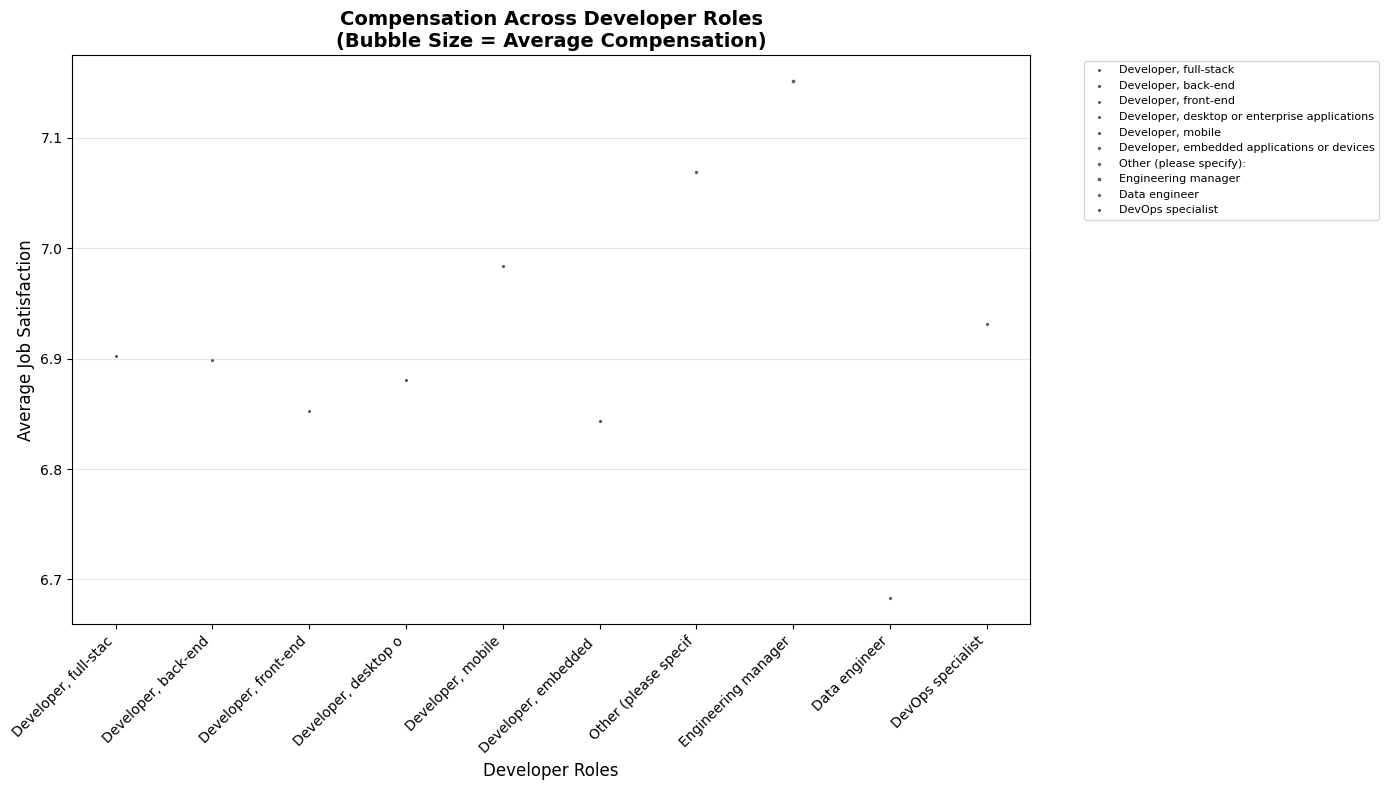

In [8]:
# Task 3.1: Bubble Plot for Compensation Across Developer Roles
# Extract compensation and developer type
df_roles = df[['DevType', 'ConvertedCompYearly', 'JobSat']].dropna()

# Convert to numeric
df_roles['ConvertedCompYearly'] = pd.to_numeric(df_roles['ConvertedCompYearly'], errors='coerce')
df_roles['JobSat'] = pd.to_numeric(df_roles['JobSat'], errors='coerce')
df_roles = df_roles.dropna()

# Get top 10 developer roles
top_roles = df_roles['DevType'].value_counts().head(10)

# Create bubble plot
plt.figure(figsize=(14, 8))
role_colors = plt.cm.tab10(range(len(top_roles)))

for idx, (role, count) in enumerate(top_roles.items()):
    df_role = df_roles[df_roles['DevType'] == role]
    avg_comp = df_role['ConvertedCompYearly'].mean()
    avg_sat = df_role['JobSat'].mean()
    
    plt.scatter(idx, avg_sat, 
               s=avg_comp/50000, alpha=0.6, 
               c=[role_colors[idx]], edgecolors='black', linewidth=1,
               label=role)

plt.xlabel('Developer Roles', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.title('Compensation Across Developer Roles\n(Bubble Size = Average Compensation)', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_roles)), [r[:20] for r in top_roles.index], rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


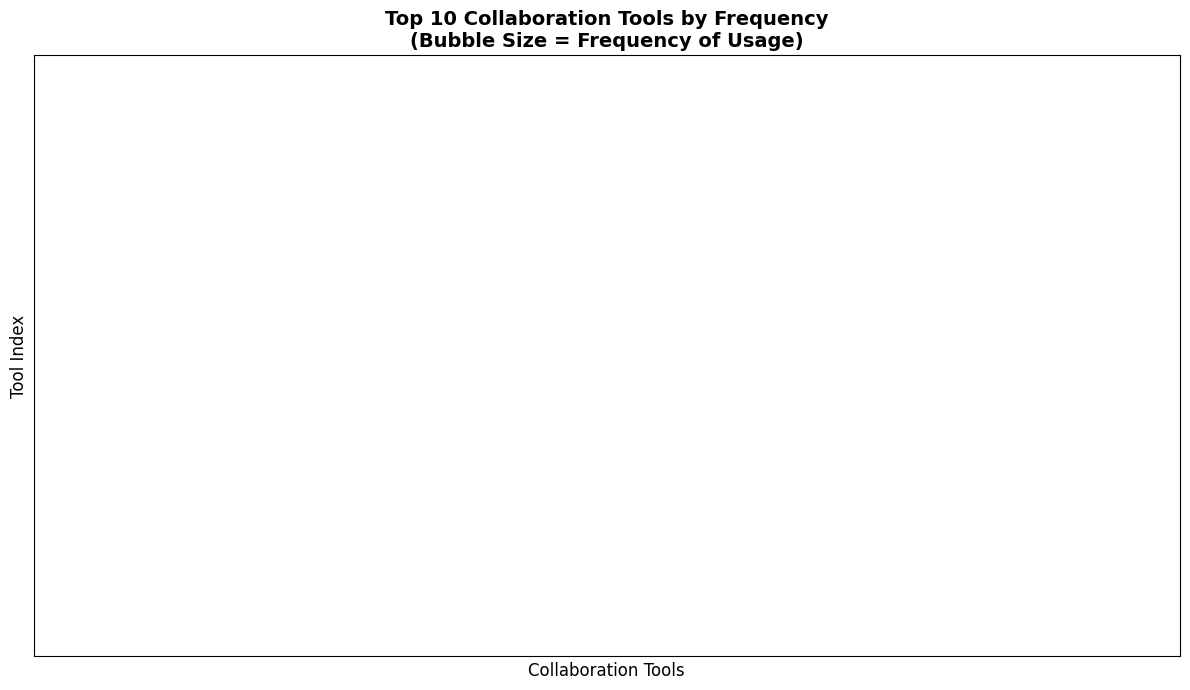

In [9]:
# Task 3.2: Bubble Plot for Collaboration Tools by Age
# Extract collaboration tools and age
df_tools = df[['NEWCollabToolsHaveWorkedWith', 'Age']].dropna()

# Convert age to numeric
df_tools['Age'] = pd.to_numeric(df_tools['Age'], errors='coerce')
df_tools = df_tools.dropna()

# Count tools by frequency
tool_counts = {}
for tools_str in df_tools['NEWCollabToolsHaveWorkedWith']:
    if pd.notna(tools_str):
        for tool in str(tools_str).split(';'):
            tool = tool.strip()
            if tool:
                tool_counts[tool] = tool_counts.get(tool, 0) + 1

# Get top 10 tools
top_tools = sorted(tool_counts.items(), key=lambda x: x[1], reverse=True)[:10]
tool_names = [x[0] for x in top_tools]
tool_freqs = [x[1] for x in top_tools]

# Create bubble plot
plt.figure(figsize=(12, 7))
colors = plt.cm.Spectral(range(len(tool_names)))
plt.scatter(range(len(tool_names)), range(len(tool_names)),
           s=[freq*2 for freq in tool_freqs],
           alpha=0.6, c=colors, edgecolors='black', linewidth=1)

plt.xlabel('Collaboration Tools', fontsize=12)
plt.ylabel('Tool Index', fontsize=12)
plt.title('Top 10 Collaboration Tools by Frequency\n(Bubble Size = Frequency of Usage)', fontsize=14, fontweight='bold')
plt.xticks(range(len(tool_names)), tool_names, rotation=45, ha='right')
plt.yticks([])
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



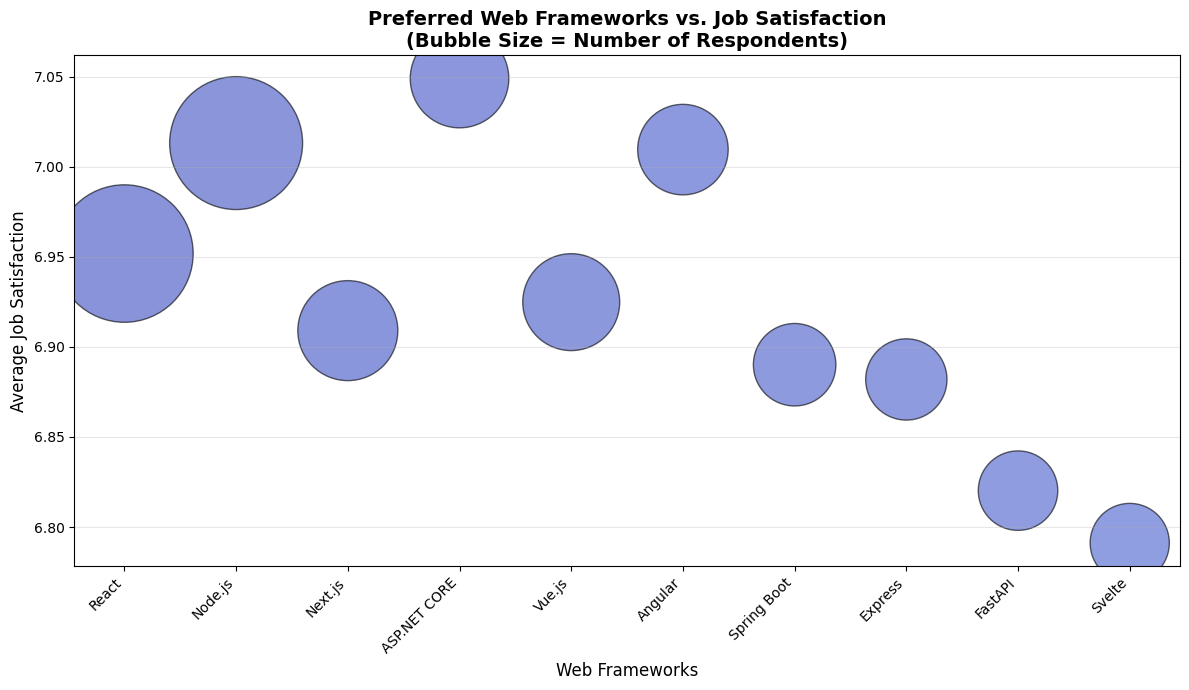

In [10]:
# Task 4.1: Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction
# Extract web frameworks and job satisfaction
df_web = df[['WebframeWantToWorkWith', 'JobSat']].dropna()

# Count frameworks and calculate satisfaction
fw_counts = {}
fw_satisfaction = {}

for idx, row in df_web.iterrows():
    frameworks = str(row['WebframeWantToWorkWith']).split(';')
    for fw in frameworks:
        fw = fw.strip()
        if fw:
            if fw not in fw_counts:
                fw_counts[fw] = 0
                fw_satisfaction[fw] = []
            fw_counts[fw] += 1
            fw_satisfaction[fw].append(pd.to_numeric(row['JobSat'], errors='coerce'))

# Get top 10 frameworks
top_fws = sorted(fw_counts.items(), key=lambda x: x[1], reverse=True)[:10]
fw_names = [x[0] for x in top_fws]
fw_freqs = [x[1] for x in top_fws]
fw_avg_sat = [sum([s for s in fw_satisfaction[fw] if pd.notna(s)])/len([s for s in fw_satisfaction[fw] if pd.notna(s)])
              for fw in fw_names]

# Create bubble plot
plt.figure(figsize=(12, 7))
colors = plt.cm.coolwarm(range(len(fw_names)))
plt.scatter(range(len(fw_names)), fw_avg_sat,
           s=[freq*1.2 for freq in fw_freqs],
           alpha=0.6, c=colors, edgecolors='black', linewidth=1)

plt.xlabel('Web Frameworks', fontsize=12)
plt.ylabel('Average Job Satisfaction', fontsize=12)
plt.title('Preferred Web Frameworks vs. Job Satisfaction\n(Bubble Size = Number of Respondents)', fontsize=14, fontweight='bold')
plt.xticks(range(len(fw_names)), fw_names, rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



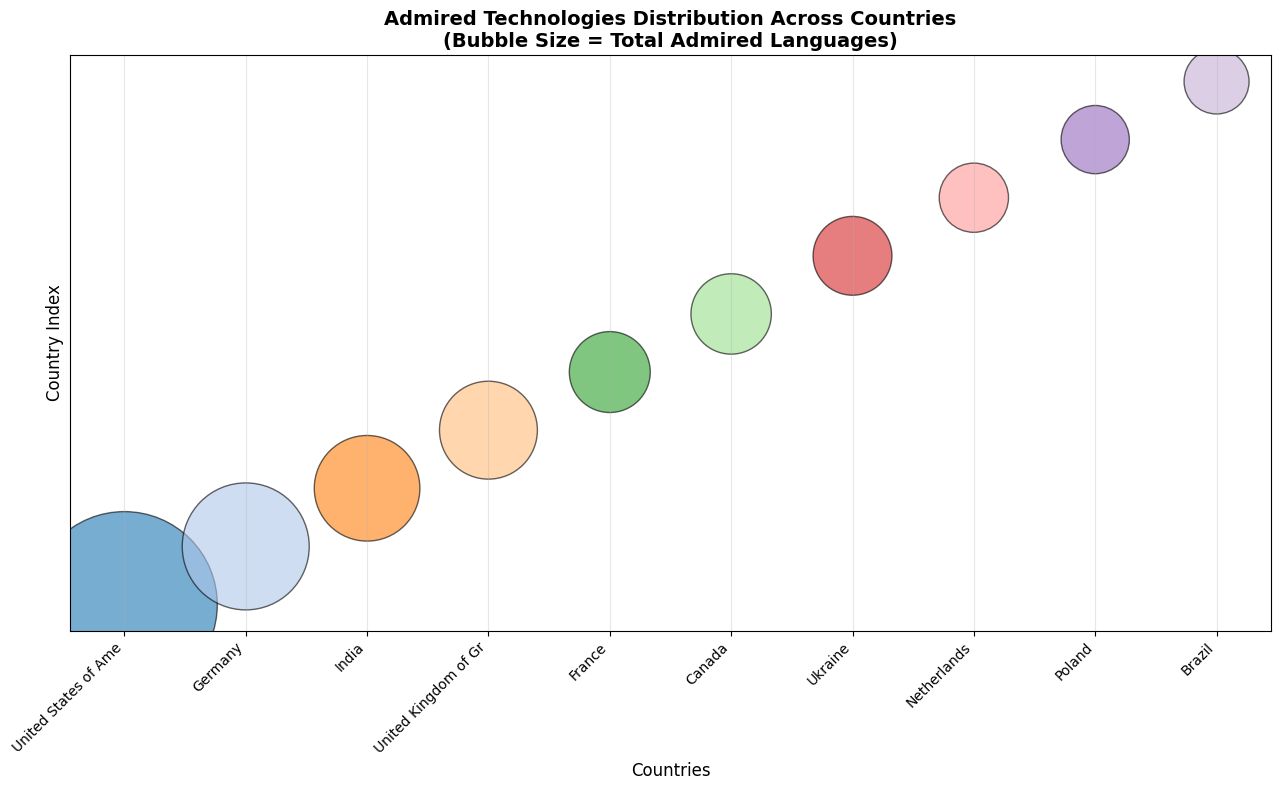

In [11]:
# Task 4.2: Bubble Plot for Admired Technologies Across Countries
# Extract admired languages and country
df_admired = df[['LanguageAdmired', 'Country']].dropna()

# Count languages by country
lang_by_country = {}
for idx, row in df_admired.iterrows():
    country = str(row['Country']).strip()
    if country and country != 'nan':
        if country not in lang_by_country:
            lang_by_country[country] = {}
        
        languages = str(row['LanguageAdmired']).split(';')
        for lang in languages:
            lang = lang.strip()
            if lang and lang != 'nan':
                lang_by_country[country][lang] = lang_by_country[country].get(lang, 0) + 1

# Get top 10 countries
top_countries_list = sorted([(c, sum(ldict.values())) for c, ldict in lang_by_country.items()],
                           key=lambda x: x[1], reverse=True)[:10]
top_countries = [x[0] for x in top_countries_list]
country_lang_counts = [x[1] for x in top_countries_list]

# Create bubble plot
plt.figure(figsize=(13, 8))
colors = plt.cm.tab20(range(len(top_countries)))
plt.scatter(range(len(top_countries)), range(len(top_countries)),
           s=[count*0.5 for count in country_lang_counts],
           alpha=0.6, c=colors, edgecolors='black', linewidth=1)

plt.xlabel('Countries', fontsize=12)
plt.ylabel('Country Index', fontsize=12)
plt.title('Admired Technologies Distribution Across Countries\n(Bubble Size = Total Admired Languages)', fontsize=14, fontweight='bold')
plt.xticks(range(len(top_countries)), [c[:20] if len(c) > 20 else c for c in top_countries], rotation=45, ha='right')
plt.yticks([])
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
